# Exoplanet Analysis Tools - 06: Joint photometry + RV + Rossiter-McLaughlin fit of WASP-108 b

This notebook brings everything together: a **single joint MCMC fit** that models, at the
same time,

- **space-based photometry** — four sectors of TESS 2-minute data (many transits, tight
  ephemeris and geometry),
- **ground-based photometry** — one high-cadence transit from the **0.6-m telescope of the
  Observatorio do Pico dos Dias (OPD/LNA, Brazil)**, taken on the *same night* as the
  spectroscopic transit,
- **orbital radial velocities** — CORALIE RVs that pin down the planet mass, and
- **Rossiter-McLaughlin radial velocities** — the GHOST transit sequence that measures the
  sky-projected spin-orbit obliquity.

All of these share one set of planet parameters, so the photometry constrains the transit
geometry while the RVs constrain the mass and the RM anomaly constrains the obliquity — the
strongest possible constraint on the system.

### Data provenance

The **CORALIE orbital RVs** (`data/WASP-108/WASP-108_coralie.rdb`) are reconstructed from
the published best-fit circular Keplerian orbit of
[Anderson et al. (2015), MNRAS 448, 1952](https://ui.adsabs.harvard.edu/abs/2015MNRAS.448.1952A/abstract)
(arXiv:1410.3449), as shown in their Figure 2, using the Table 6 parameters
(P, Tc, K = 117.8 m/s, gamma = 47.07 km/s, e = 0). Please cite Anderson et al. (2015) when
using these RVs. The GHOST RM RVs and the OPD and TESS light curves are real observations.

## 1. Load the photometry

We build a list of transit windows from all photometric datasets: the four TESS sectors
(binned from 2-min to 10-min to speed up the demo) and the single OPD transit (binned from
its ~10-second cadence to 2 minutes). Each window is normalized by its out-of-transit
median; the transit fit then models each window with a transit x calibration-polynomial.

In [1]:
%matplotlib inline
import glob, os, shutil
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as fits
from exoplanet_analysis import fitlib, rvutils, priorslib, rmlib

DATA = "data/WASP-108/"
os.makedirs("outputs", exist_ok=True)
priors_file = "outputs/WASP-108_joint.pars"
shutil.copyfile(DATA + "WASP-108_joint.pars", priors_file)

# WASP-108 b ephemeris (Anderson et al. 2015); the transit we observed is epoch 1369
Tc0, P0 = 2460076.6131, 2.6755463

def select_windows(t, f, ef, per, tc, window=0.18, min_pts=10, bin_to=None):
    """Cut normalized windows around each predicted transit."""
    e0, e1 = int(np.ceil((t.min()-tc)/per)), int(np.floor((t.max()-tc)/per))
    T, F, E = [], [], []
    for e in range(e0, e1+1):
        tt = tc + e*per
        m = np.abs(t-tt) < window
        if np.sum(m) < min_pts:
            continue
        wt, wf, we = t[m], f[m], ef[m]
        oot = np.abs(wt-tt) > 0.6*window
        norm = np.median(wf[oot]) if np.sum(oot) > 3 else np.median(wf)
        wf, we = wf/norm, we/norm
        if bin_to is not None:
            wt, wf, we = fitlib.bin_data(wt, wf, we, median=False, binsize=bin_to)
            ok = np.isfinite(wf) & np.isfinite(we)
            wt, wf, we = wt[ok], wf[ok], we[ok]
        T.append(wt); F.append(wf); E.append(we)
    return T, F, E

times, fluxes, fluxerrs = [], [], []
window_labels = []

# --- TESS sectors (PDCSAP flux) ---
for fn in sorted(glob.glob(DATA + "tess*.fits"))[:2]:  # 2 sectors keep the demo fast
    d = fits.getdata(fn, 1)
    t = d["TIME"] + 2457000.0
    fl = d["PDCSAP_FLUX"]; q = d["QUALITY"]
    good = np.isfinite(t) & np.isfinite(fl) & (q == 0)
    t, fl = t[good], fl[good]
    fe = np.full_like(fl, np.nanstd(np.diff(fl)) / np.sqrt(2))
    wt, wf, we = select_windows(t, fl, fe, P0, Tc0, window=0.18, bin_to=10./60/24)
    sector = fn.split("-s0")[1][:3]
    times += wt; fluxes += wf; fluxerrs += we
    window_labels += ["TESS s{}".format(sector)] * len(wt)
    print("TESS sector {}: {} transit windows".format(sector, len(wt)))

# --- OPD/LNA 0.6-m single transit ---
hdul = fits.open(DATA + "WASP-108_opd_bc06_lc.fits")
t = np.array(hdul[1].data); f = np.array(hdul[2].data); fe = np.array(hdul[3].data)
hdul.close()
good = np.isfinite(t) & np.isfinite(f) & np.isfinite(fe)
wt, wf, we = select_windows(t[good], f[good], fe[good], P0, Tc0, window=0.20, bin_to=2./60/24)
times += wt; fluxes += wf; fluxerrs += we
window_labels += ["OPD 0.6m"] * len(wt)
print("OPD 0.6m: {} transit window(s), {} binned points".format(len(wt), len(wt[0]) if wt else 0))
print("total photometry windows: {}".format(len(times)))

TESS sector 011: 7 transit windows


TESS sector 037: 8 transit windows
OPD 0.6m: 1 transit window(s), 238 binned points
total photometry windows: 16


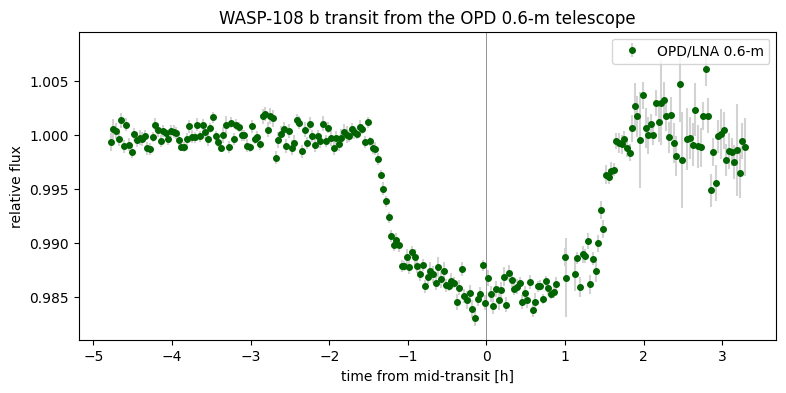

In [2]:
# The OPD transit (the one we also observed spectroscopically)
opd_i = window_labels.index("OPD 0.6m")
plt.figure(figsize=(9, 4))
plt.errorbar((times[opd_i]-Tc0)*24, fluxes[opd_i], yerr=fluxerrs[opd_i],
             fmt="o", ms=4, color="darkgreen", ecolor="lightgray", label="OPD/LNA 0.6-m")
plt.axvline(0, color="grey", lw=0.6)
plt.xlabel("time from mid-transit [h]"); plt.ylabel("relative flux")
plt.title("WASP-108 b transit from the OPD 0.6-m telescope"); plt.legend()
plt.show()

## 2. Load the radial velocities

Three RV datasets: the **CORALIE** orbital RVs (which sample the full orbit and constrain
the mass) and the **GHOST blue/red** RVs (taken across the transit, carrying the RM
anomaly). All are in km/s, so we keep them in km/s (`conv_factor=1`) to match the units of
`vsini`.

In [3]:
rv_files = [DATA + "WASP-108_coralie.rdb",
            DATA + "WASP-108_ghost_blue_ccfrv_corr.rdb",
            DATA + "WASP-108_ghost_red_ccfrv_corr.rdb"]
rvlabels = ["CORALIE (orbit)", "GHOST blue (RM)", "GHOST red (RM)"]

bjds, rvs, rverrs = [], [], []
for fp in rv_files:
    b, r, e = rvutils.read_rv_time_series(fp, conv_factor=1.)
    ok = np.isfinite(r) & np.isfinite(e)
    bjds.append(b[ok]); rvs.append(r[ok]); rverrs.append(e[ok])
    print("{:18s}: {:2d} RVs, median {:.4f} km/s".format(rvlabels[len(bjds)-1], int(np.sum(ok)), np.median(r[ok])))

CORALIE (orbit)   : 23 RVs, median 47.1143 km/s
GHOST blue (RM)   : 27 RVs, median 48.5304 km/s
GHOST red (RM)    : 56 RVs, median 48.5308 km/s


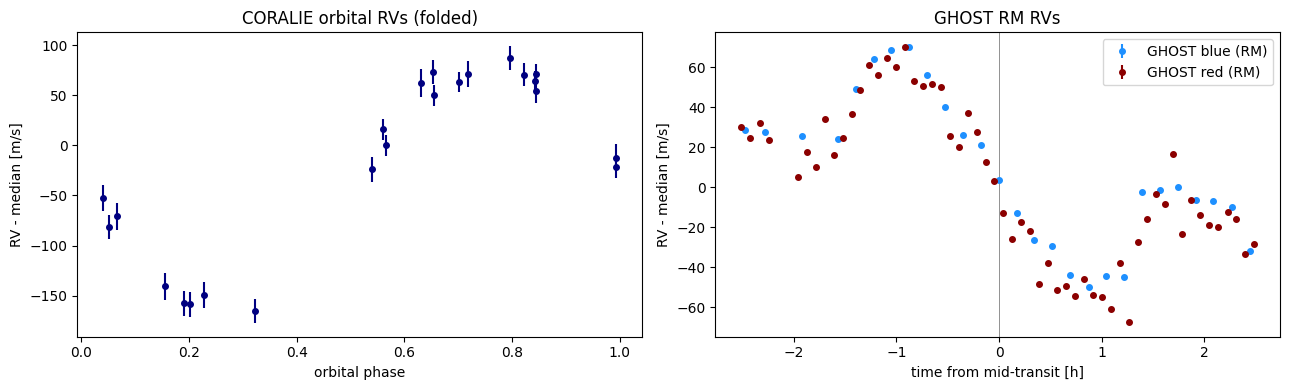

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# orbital RVs folded on the period
ph = ((bjds[0]-Tc0)/P0) % 1.0
axes[0].errorbar(ph, (rvs[0]-np.median(rvs[0]))*1000, yerr=rverrs[0]*1000, fmt="o", ms=4, color="navy")
axes[0].set_xlabel("orbital phase"); axes[0].set_ylabel("RV - median [m/s]")
axes[0].set_title("CORALIE orbital RVs (folded)")
# RM RVs vs time from mid-transit
for i, c in ((1, "dodgerblue"), (2, "darkred")):
    axes[1].errorbar((bjds[i]-Tc0)*24, (rvs[i]-np.median(rvs[i]))*1000, yerr=rverrs[i]*1000,
                     fmt="o", ms=4, color=c, label=rvlabels[i])
axes[1].axvline(0, color="grey", lw=0.6)
axes[1].set_xlabel("time from mid-transit [h]"); axes[1].set_ylabel("RV - median [m/s]")
axes[1].set_title("GHOST RM RVs"); axes[1].legend()
plt.tight_layout(); plt.show()

## 3. The joint fit

The priors file `WASP-108_joint.pars` contains all three families of parameters: orbital
(`k`, `tc`, `per`), transit-geometry (`a`, `rp`, `inc`, `u0`, `u1`), and Rossiter-McLaughlin
(`lambda`, `vsini`, `ldc`). We read them with `read_transit_rv_priors`, initialize the
photometric and RV calibration, refine with a least-squares step, and then run the joint
MCMC with **`include_rm=True`** so the RM anomaly is added to the RV model.

Because the free parameters span very different scales (an obliquity that ranges over
+/-180 deg alongside a transit time known to ~1e-4 d), we let the walkers start from a
prior-scaled ball (`scaled_ball=True`, the default), which spreads each parameter according
to the width of its prior.

In [5]:
priors = fitlib.read_transit_rv_priors(priors_file, len(rvs), len(times),
                                       calib_polyorder=1, verbose=False)
posterior = fitlib.guess_calib_transit_rv(priors, times, fluxes, bjds, rvs,
                                          prior_type="FIXED", remove_transits=True,
                                          rv_prior_type="Normal", plot=False)
print("free parameters ({}):".format(len(posterior["theta"])), posterior["labels"])

posterior = fitlib.fitTransits_and_RVs_ols(times, fluxes, fluxerrs, bjds, rvs, rverrs, posterior,
                                           fix_eccentricity=True, calib_post_type="FIXED",
                                           rvcalib_post_type="Normal", calib_unc=0.01,
                                           verbose=False, plot=False)

median_rv (no prior model considered) =  47.11434
median_rv= 47.078919346820655
median_rv (no prior model considered) =  48.53038
median_rv= 48.54386591109704
median_rv (no prior model considered) =  48.53078
median_rv= 48.53426614410514
free parameters (13): ['a_000', 'rp_000', 'inc_000', 'u0_000', 'u1_000', 'k_000', 'tc_000', 'per_000', 'lambda_000', 'vsini_000', 'rv_d00', 'rv_d01', 'rv_d02']
Free parameters before OLS fit:
a_000 = 7.05
rp_000 = 0.1087
inc_000 = 88.49
k_000 = 0.1178
tc_000 = 2460076.6131
per_000 = 2.6755463
lambda_000 = 0.0
vsini_000 = 4.7
rv_d00 = 47.078919346820655
rv_d01 = 48.54386591109704
rv_d02 = 48.53426614410514
Free parameters after OLS fit:
a_000 = 6.219642116070605
rp_000 = 0.11399722788984012
inc_000 = 83.51069133483438
u0_000 = 0.45
u1_000 = 0.22
k_000 = 0.16543937665501585
tc_000 = 2460076.616192054
per_000 = 2.6755405634895313
lambda_000 = 0.0
vsini_000 = 4.7
rv_d00 = 47.06469028127895
rv_d01 = 48.54085535041469
rv_d02 = 48.532713808164935


### Limb darkening across bandpasses

WASP-108 is observed here in three different (but overlapping) bandpasses: the **TESS**
band, the **OPD/LNA 0.6-m I band**, and the **GHOST** spectrograph (roughly 400-700 nm)
used for the RM. The stellar limb darkening depends on wavelength, so in principle each
bandpass has its own coefficients.

The package lets you choose how to handle this. Here we keep it simple and let the RM model
**share** the transit limb darkening (the joint priors file omits ``ldc``), so the RM uses
the fitted quadratic ``u0``/``u1`` converted to an effective linear coefficient. Because the
three bands overlap substantially, this is a reasonable first approximation and reduces the
number of free parameters. `rmlib.rm_ldc_report` tells us exactly what is being used, and
the fit prints it when ``verbose=True``:

In [6]:
# how is the RM limb darkening configured for this fit?
print(rmlib.rm_ldc_report(priors["planet_params"], 0))

# If instead you wanted a more precise, band-specific treatment, you could either:
#  - add an `ldc_000` prior to the joint priors file to give the GHOST RM its own
#    limb-darkening coefficient (different bandpass), or
#  - assign the photometry datasets to separate instruments (bandpasses) with their own
#    u0_inst/u1_inst coefficients (TESS vs OPD), and tie the RM to the matching one.
print("effective linear eps used by the RM model:",
      round(rmlib.quadratic_to_linear_ld(priors['planet_params']['u0_000'],
                                          priors['planet_params']['u1_000']), 4))

RM limb darkening: TIED to the transit limb darkening (u0_000/u1_000 -> linear eps = 0.5967); RM and transit share the same bandpass. Add an ldc_000 prior to use an independent coefficient instead.
effective linear eps used by the RM model: 0.5967


In [7]:
posterior = fitlib.fitTransitsAndRVsWithMCMC(
    times, fluxes, fluxerrs, bjds, rvs, rverrs, posterior,
    amp=1e-3, nwalkers=32, niter=700, burnin=250,
    samples_filename="outputs/WASP-108_joint_samples.h5",
    include_rm=True, scaled_ball=True,
    verbose=True, plot=False, rvdatalabels=rvlabels, timelabel="BJD")

Free parameters before MCMC fit:
a_000 = 7.05
rp_000 = 0.1087
inc_000 = 88.49
u0_000 = 0.45
u1_000 = 0.22
k_000 = 0.1178
tc_000 = 2460076.6131
per_000 = 2.6755463
lambda_000 = 0.0
vsini_000 = 4.7
rv_d00 = 47.06469028127895
rv_d01 = 48.54085535041469
rv_d02 = 48.532713808164935
RM limb darkening: TIED to the transit limb darkening (u0_000/u1_000 -> linear eps = 0.5967); RM and transit share the same bandpass. Add an ldc_000 prior to use an independent coefficient instead.
initializing emcee sampler ...
Running MCMC ...
N_walkers= 32  ndim= 13


  0%|          | 0/700 [00:00<?, ?it/s]

  0%|          | 2/700 [00:00<00:39, 17.69it/s]

  1%|          | 4/700 [00:00<00:39, 17.56it/s]

  1%|          | 6/700 [00:00<00:39, 17.39it/s]

...

 99%|█████████▉| 696/700 [00:40<00:00, 16.57it/s]

100%|█████████▉| 698/700 [00:40<00:00, 16.86it/s]

100%|██████████| 700/700 [00:40<00:00, 16.94it/s]

100%|██████████| 700/700 [00:40<00:00, 17.32it/s]

Obtaining best fit calibration parameters from pdfs ...
CALIBRATION Fit parameters:
----------------
Output CALIBRATION posterior:  calibration_posterior.pars
Obtaining best fit RV calibration parameters from pdfs ...
RV CALIBRATION Fit parameters:
rv_d00 = 47.07133438975389 + 0.09031452869419354 - 0.06209444083031457
rv_d01 = 48.5434072870448 + 0.00036228001274452026 - 0.00045448222082455914
rv_d02 = 48.53717519107478 + 0.0007478714818134335 - 0.00019927651637630106
----------------
Output RV CALIBRATION posterior:  calibration_posterior.pars
Obtaining best fit planet parameters from pdfs ...
----------------
PLANET 2 Fit parameters:
a_000 = 7.386156683208287 + 0.017708140556636387 - 0.06026327349237892
----------------
rp_000 = 0.11569871452260609 + 0.00022844232464848402 - 0.0005108173137698818
----------------
inc_000 = 88.03306832660279 + 0.1632937329480626 - 0.09086753263837011
----------------
u0_000 = 0.44679695979615874 + 0.0036275297540417917 - 0.007273589673285119
----------

## 4. Results

The joint fit constrains the geometry (from photometry), the mass (from the CORALIE orbit),
and the obliquity (from the GHOST RM), all at once. Compare with Anderson et al. (2015):
K = 117.8 +/- 3.5 m/s, a/Rs = 7.05 +/- 0.13, i = 88.49 +/- 0.84 deg, Rp/Rs ~ 0.109. The
sky-projected obliquity lambda is consistent with an aligned orbit.

In [8]:
pp = posterior["planet_params"]

def show(name, key, unit="", scale=1.0, ref=""):
    v = pp[key] * scale
    print("  {:22s} = {:12.5f} {:8s}   {}".format(name, v, unit, ref))

print("Joint fit results (WASP-108 b):")
show("Period", "per_000", "d", ref="Anderson+2015: 2.6755463")
show("Transit time", "tc_000", "BJD")
show("K (semi-amplitude)", "k_000", "m/s", 1000.0, "Anderson+2015: 117.8 +/- 3.5")
show("a/Rstar", "a_000", "", 1.0, "Anderson+2015: 7.05 +/- 0.13")
show("Inclination", "inc_000", "deg", 1.0, "Anderson+2015: 88.49 +/- 0.84")
show("Rp/Rstar", "rp_000", "", 1.0, "Anderson+2015: ~0.109")
show("lambda (obliquity)", "lambda_000", "deg", 1.0, "aligned: ~0")
show("v sin i", "vsini_000", "km/s", 1.0, "spectroscopic: 4.7 +/- 0.8")

Joint fit results (WASP-108 b):
  Period                 =      2.67555 d          Anderson+2015: 2.6755463
  Transit time           = 2460076.61303 BJD        
  K (semi-amplitude)     =    124.01344 m/s        Anderson+2015: 117.8 +/- 3.5
  a/Rstar                =      7.38616            Anderson+2015: 7.05 +/- 0.13
  Inclination            =     88.03307 deg        Anderson+2015: 88.49 +/- 0.84
  Rp/Rstar               =      0.11570            Anderson+2015: ~0.109
  lambda (obliquity)     =     17.32140 deg        aligned: ~0
  v sin i                =      4.77685 km/s       spectroscopic: 4.7 +/- 0.8


### The RM anomaly with the best-fit model

Overlaying the fitted orbit + RM model on the GHOST data (systemic velocity removed) shows
the anomaly the fit has measured: 

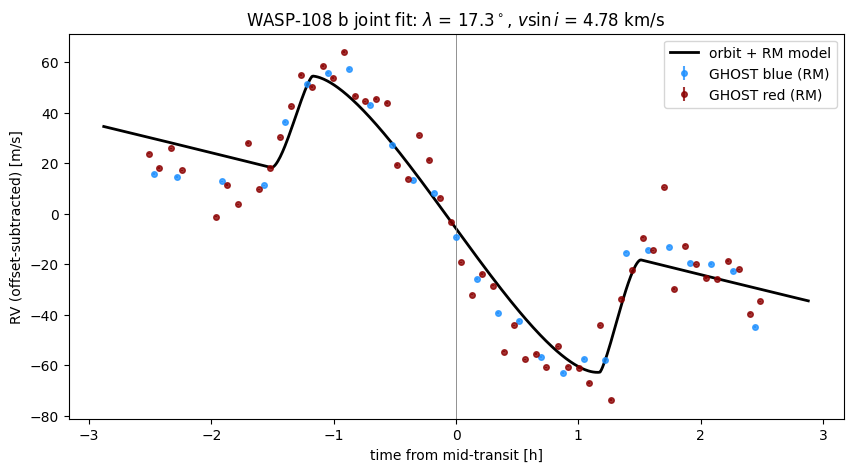

In [9]:
rc = posterior["rvcalib_params"]
tmodel = np.linspace(Tc0-0.12, Tc0+0.12, 600)
rm_full = rmlib.rm_model(tmodel, pp, 0, include_orbit=True, include_trend=False)

plt.figure(figsize=(10, 5))
for i, c in ((1, "dodgerblue"), (2, "darkred")):
    off = rc["rv_d{0:02d}".format(i)]
    plt.errorbar((bjds[i]-Tc0)*24, (rvs[i]-off)*1000, yerr=rverrs[i]*1000,
                 fmt="o", ms=4, color=c, label=rvlabels[i], alpha=0.8)
# subtract the orbital RV at mid-transit so the model shows the anomaly around zero
orbit_only = rmlib.rm_model(tmodel, pp, 0, include_orbit=True, include_trend=False) - \
             rmlib.rm_rv_anomaly(tmodel, pp, 0)
plt.plot((tmodel-Tc0)*24, (rm_full - np.median(orbit_only))*1000, "-", color="k", lw=2,
         label="orbit + RM model")
plt.axvline(0, color="grey", lw=0.6)
plt.xlabel("time from mid-transit [h]"); plt.ylabel("RV (offset-subtracted) [m/s]")
plt.title(r"WASP-108 b joint fit: $\lambda$ = {:.1f}$^\circ$, $v\sin i$ = {:.2f} km/s".format(
    pp["lambda_000"], pp["vsini_000"]))
plt.legend()
plt.show()

### Phase-folded transit (all photometry)

All the photometric windows folded on the fitted ephemeris, with the best-fit transit
model: 

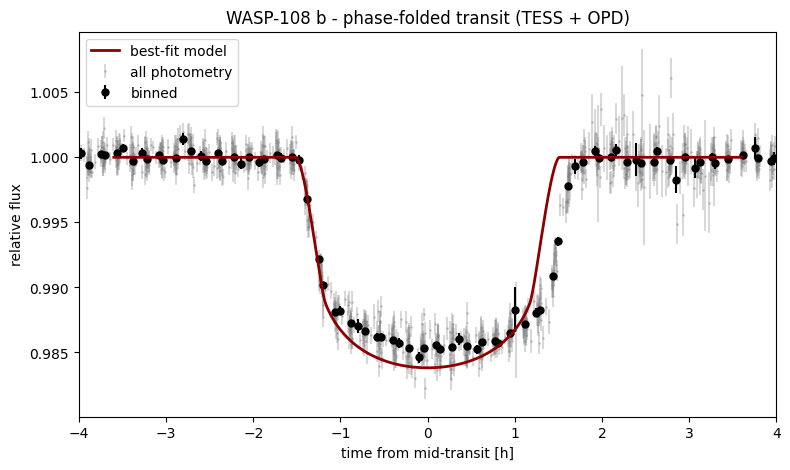

In [10]:
from exoplanet_analysis import exoplanetlib
per_fit, tc_fit = pp["per_000"], pp["tc_000"]
phase = np.array([]); nflux = np.array([]); nerr = np.array([])
for i in range(len(times)):
    ph = (times[i]-tc_fit+0.5*per_fit) % per_fit - 0.5*per_fit
    phase = np.append(phase, ph); nflux = np.append(nflux, fluxes[i]); nerr = np.append(nerr, fluxerrs[i])
srt = np.argsort(phase); phase, nflux, nerr = phase[srt], nflux[srt], nerr[srt]
bt, bf, be = fitlib.bin_data(phase, nflux, nerr, median=False, binsize=0.004)

tm = np.linspace(tc_fit-0.15, tc_fit+0.15, 800)
fm = exoplanetlib.batman_transit_model(tm, pp)

plt.figure(figsize=(9, 5))
plt.errorbar(phase*24, nflux, yerr=nerr, fmt=".", ms=2, color="grey", alpha=0.3, zorder=1, label="all photometry")
plt.errorbar(bt*24, bf, yerr=be, fmt="o", ms=5, color="k", zorder=2, label="binned")
plt.plot((tm-tc_fit)*24, fm, "-", color="darkred", lw=2, zorder=3, label="best-fit model")
plt.xlabel("time from mid-transit [h]"); plt.ylabel("relative flux")
plt.title("WASP-108 b - phase-folded transit (TESS + OPD)"); plt.legend(); plt.xlim(-4, 4)
plt.show()

### Corner plot of the key parameters

We show the joint posterior for the parameters of primary interest — the mass proxy K, the
geometry, and the obliquity: 

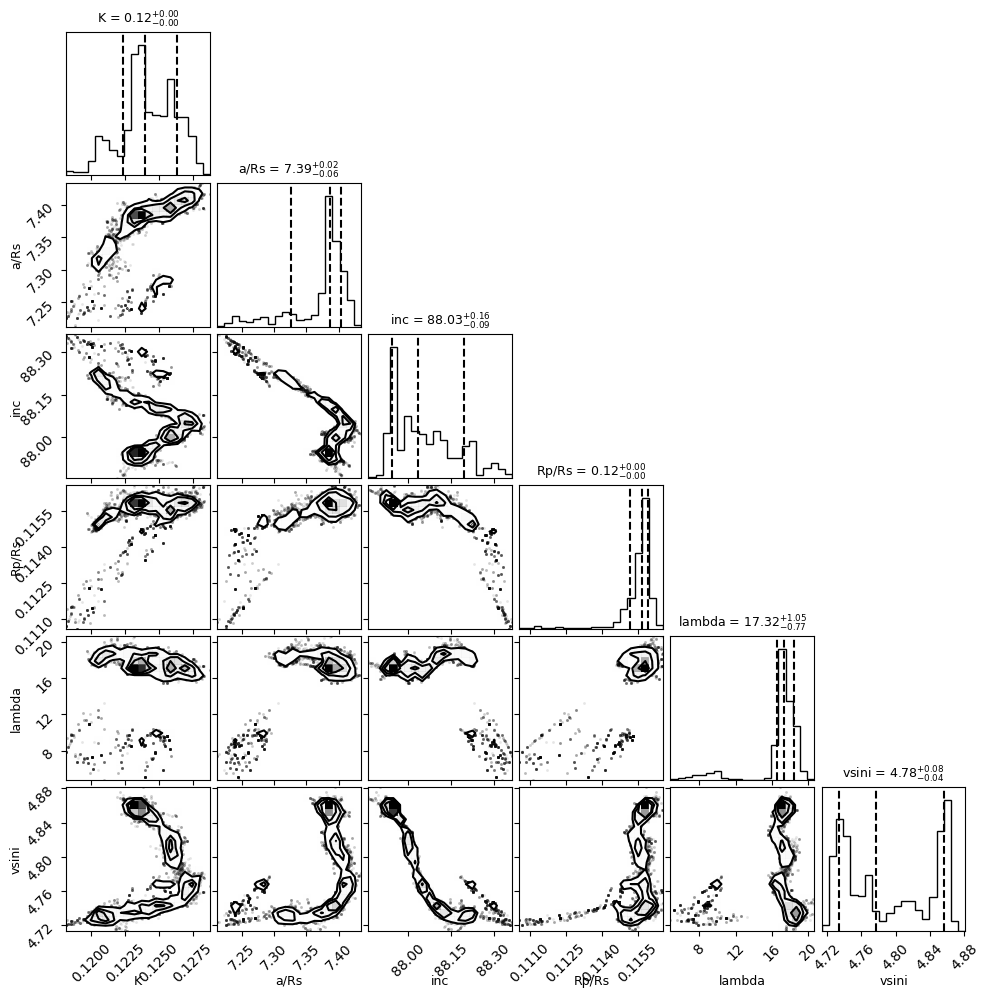

In [11]:
import corner, emcee
backend = emcee.backends.HDFBackend("outputs/WASP-108_joint_samples.h5", read_only=True)
flat = backend.get_chain(discard=250, flat=True)
labels = list(posterior["labels"])
want = ["k_000", "a_000", "inc_000", "rp_000", "lambda_000", "vsini_000"]
idx = [labels.index(w) for w in want if w in labels]
sub = flat[:, idx]
nice = {"k_000": "K", "a_000": "a/Rs", "inc_000": "inc", "rp_000": "Rp/Rs",
        "lambda_000": "lambda", "vsini_000": "vsini"}
fig = corner.corner(sub, labels=[nice[want[j]] for j in range(len(idx))],
                    quantiles=[0.16, 0.5, 0.84], show_titles=True,
                    title_kwargs={"fontsize": 9}, label_kwargs={"fontsize": 9})
fig.set_size_inches(10, 10)
plt.show()

## 5. The output parameter file

The joint posterior — orbital, geometric, and RM parameters together — is written to a
single `.pars` file (and its JSON mirror), reflecting the RM parameters alongside the
transit and orbit: 

In [12]:
print(open("outputs/WASP-108_joint_posterior.pars").read())

# Parameter_ID	Prior_Type	Values
teff	FIXED	5960.0
ms	FIXED	1.167
rs	FIXED	1.215
n_planets	FIXED	1.0
a_000	Normal	7.3861566832,0.0389857070
rp_000	Normal	0.1156987145,0.0003696298
inc_000	Normal	88.0330683266,0.1270806328
u0_000	Normal	0.4467969598,0.0054505597
u1_000	Normal	0.2245064520,0.0028157987
transit_000	FIXED	1.0
k_000	Normal	0.1240134444,0.0020082569
tc_000	Normal	2460076.6130276569,0.0000153745
per_000	Normal	2.6755464602,0.0000000414
esinw_000	FIXED	0.0
ecosw_000	FIXED	0.0
rvsys_000	FIXED	0.0
trend_000	FIXED	0.0
quadtrend_000	FIXED	0.0
lambda_000	Normal	17.3214040856,0.9122886257
vsini_000	Normal	4.7768510798,0.0612031047
omega_rm_000	FIXED	90.0



### Summary

This notebook demonstrated the full capability of the package: a single MCMC fit combining
space- and ground-based photometry, orbital RVs, and Rossiter-McLaughlin RVs, sharing one
set of planet parameters. The photometry fixes the geometry, the orbital RVs fix the mass,
and the RM RVs measure the spin-orbit obliquity — with the RM anomaly added to the RV model
through `include_rm=True`. The output parameter files carry the RM parameters together with
the transit and orbital ones.

*As always, the short demo chains here underestimate the uncertainties; increase `niter`
for publication-quality posteriors, and consider fitting RV jitter and per-instrument
calibration terms.*